--- Generating Compact Horizontal Neighborhood Chart ---
Success! Compact horizontal chart saved at: E:\Projetos\ABMS-WP\figuras\figure-neighborhood-distribution-fig15.pdf


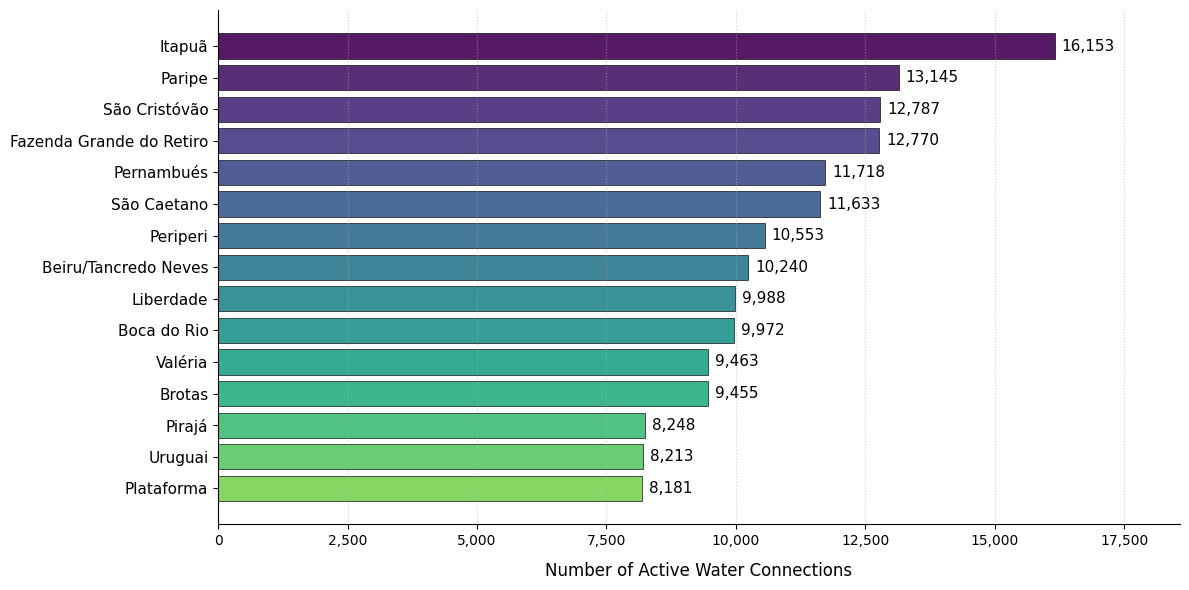

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = 'E:\\Projetos\\ABMS-WP'
INPUT_FILE = os.path.join(BASE_PATH, 'includes', 'Tabela_ligacoes_agua_Salvador.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
# Mantive o mesmo nome de arquivo conforme seu pedido
OUTPUT_FIG = 'figure-neighborhood-distribution-fig15.pdf'

def main():
    print("--- Generating Compact Horizontal Neighborhood Chart ---")

    if not os.path.exists(INPUT_FILE):
        print(f"Error: {INPUT_FILE} not found.")
        return

    # Load data
    df = pd.read_csv(INPUT_FILE, encoding='latin1')
    
    # IMPORTANT for Horizontal: Sort ascending so the biggest value ends up on top
    # when we plot (Matplotlib plots from bottom-up)
    df = df.sort_values(by='Connections', ascending=False).head(15)

    df = df.sort_values(by='Connections', ascending=True)
    # ==========================================
    # 2. Plotting (Horizontal)
    # ==========================================
    # Changed figsize: Wider (12) and much shorter height (6)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Use barh() for horizontal bars
    bars = ax.barh(df['Neighborhood'], df['Connections'], 
                  color=plt.cm.viridis(np.linspace(0.8, 0, len(df))), # Reversed color for visual logic
                  alpha=0.9, edgecolor='black', linewidth=0.5)

    # ==========================================
    # 3. Formatting (Compact & Readable)
    # ==========================================
    
    # Swapped axis labels
    ax.set_xlabel('Number of Active Water Connections', fontsize=12, labelpad=10)
    # ax.set_ylabel('Neighborhood', fontsize=12) # Often redundant in horizontal charts

    # Increase tick label size for better readability
    plt.yticks(fontsize=11) 
    plt.xticks(fontsize=10)
    
    # Format X-axis (formerly Y) with thousands separator
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    # Add padding to X-axis limits to fit the labels on the right
    ax.set_xlim(0, df['Connections'].max() * 1.15)

    # DATA LABELS (Larger and positioned at the end of bars)
    for bar in bars:
        width = bar.get_width() # Get width instead of height
        label_y_pos = bar.get_y() + bar.get_height() / 2
        
        ax.annotate(f'{int(width):,}', # Add comma separator
                    xy=(width, label_y_pos),
                    xytext=(5, 0), # 5 points horizontal offset to the right
                    textcoords="offset points",
                    ha='left', va='center', # Align left of the text to the end of bar
                    fontsize=11, # INCREASED FONT SIZE
                    fontweight='normal', color='black')

    # Clean spines (remove top and right borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Vertical grid for horizontal bars
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    
    # Tight layout is crucial here to compact the figure
    plt.tight_layout()

    # ==========================================
    # 4. Saving
    # ==========================================
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    # bbox_inches='tight' removes extra whitespace around the figure
    plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"Success! Compact horizontal chart saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()